In [2]:
import sys
import os

# Agregar el directorio raiz al PYTHONPATH
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def show_heatmap(heatmap_data, xlabel, ylabel, title, figsize=(8,6)):
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(heatmap_data, cmap="Oranges")

    # Modificar las etiquetas
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))

    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticklabels(heatmap_data.index)

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    fig.colorbar(im, ax=ax)
    plt.show()

## SVM

,accuracy,recall,precision,f1_score,model,vectorizer,regularization,kernel,vocab_size,train_time,name
0,0.723493,0.723497,0.724399,0.723543,SVM,TFIDF,0.100000,LINEAR,11819,144.087524,model_1
1,0.778087,0.778093,0.781899,0.777190,SVM,BOW,0.100000,LINEAR,11819,153.624683,model_2
2,0.730444,0.730444,0.737356,0.731054,SVM,TFIDF,0.100000,RBF,11819,196.255267,model_3
3,0.677240,0.677242,0.677905,0.677438,SVM,BOW,0.100000,RBF,11819,187.426321,model_4
4,0.757488,0.757491,0.757652,0.757332,SVM,TFIDF,0.237137,LINEAR,11819,151.486459,model_5


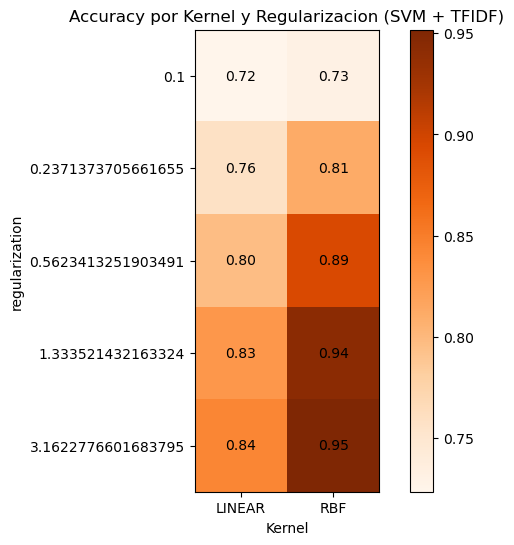

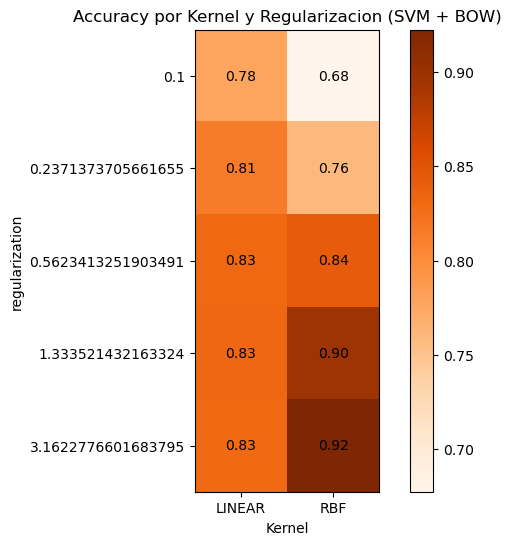

In [4]:
from constants.constants_twitter import SVM_METRICS_PATH

# Cargar datos
df_svm = pd.read_csv(SVM_METRICS_PATH)
display(df_svm.head())

# Devidir información
df_svm_tfidf = df_svm[df_svm['vectorizer'] == 'TFIDF']
df_svm_bow = df_svm[df_svm['vectorizer'] == 'BOW']

# Obtener hiperparámetros
df_svm_tfidf_data = df_svm_tfidf.pivot(index="regularization", columns="kernel", values="accuracy")
df_svm_bow_data = df_svm_bow.pivot(index="regularization", columns="kernel", values="accuracy")

# Graficar
show_heatmap(df_svm_tfidf_data, "Kernel", "regularization", "Accuracy por Kernel y Regularizacion (SVM + TFIDF)")
show_heatmap(df_svm_bow_data, "Kernel", "regularization", "Accuracy por Kernel y Regularizacion (SVM + BOW)")

## NB

,accuracy,recall,precision,f1_score,model,vectorizer,alpha,vocab_size,train_time,name
0,0.797422,0.797426,0.798695,0.797356,NB,tfidf,0.001000,11819,0.439842,model_1
1,0.778845,0.778849,0.780789,0.778551,NB,bow,0.001000,11819,0.410266,model_2
2,0.797296,0.797299,0.798531,0.797233,NB,tfidf,0.001624,11819,0.400499,model_3
3,0.778971,0.778976,0.780933,0.778675,NB,bow,0.001624,11819,0.383508,model_4
4,0.797675,0.797678,0.798888,0.797614,NB,tfidf,0.002637,11819,0.456879,model_5


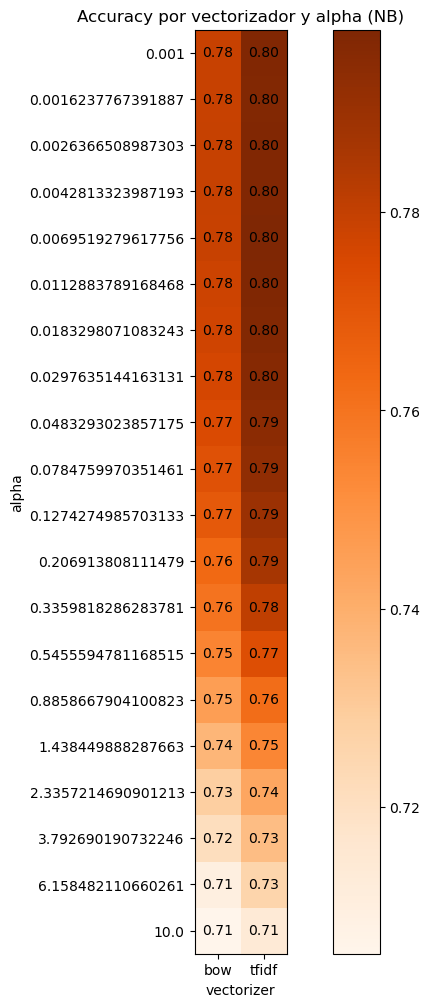

In [5]:
from constants.constants_twitter import NB_METRICS_PATH

# Cargar datos
df_nb = pd.read_csv(NB_METRICS_PATH)

display(df_nb.head())

# Obtener hiperparámetros
df_nb_data = df_nb.pivot(index="alpha", columns="vectorizer", values="accuracy")

# Graficar
show_heatmap(df_nb_data, "vectorizer", "alpha", "Accuracy por vectorizador y alpha (NB)", (12,12))


## LR

,accuracy,recall,precision,f1_score,model,vectorizer,penalty,regularization,max_iter,solver,vocab_size,train_time,name
0,0.628965,0.628969,0.633141,0.629618,LR,TFIDF,l1,0.100000,200,saga,11819,1.499777,model_1
1,0.668015,0.668022,0.669531,0.666299,LR,BOW,l1,0.100000,200,saga,11819,37.151918,model_2
2,0.674965,0.674971,0.675657,0.674907,LR,TFIDF,l1,0.266073,200,saga,11819,2.571434,model_3
3,0.698597,0.698603,0.699702,0.697398,LR,BOW,l1,0.266073,200,saga,11819,106.468896,model_4
4,0.736130,0.736133,0.735979,0.736012,LR,TFIDF,l1,0.707946,200,saga,11819,31.109224,model_5


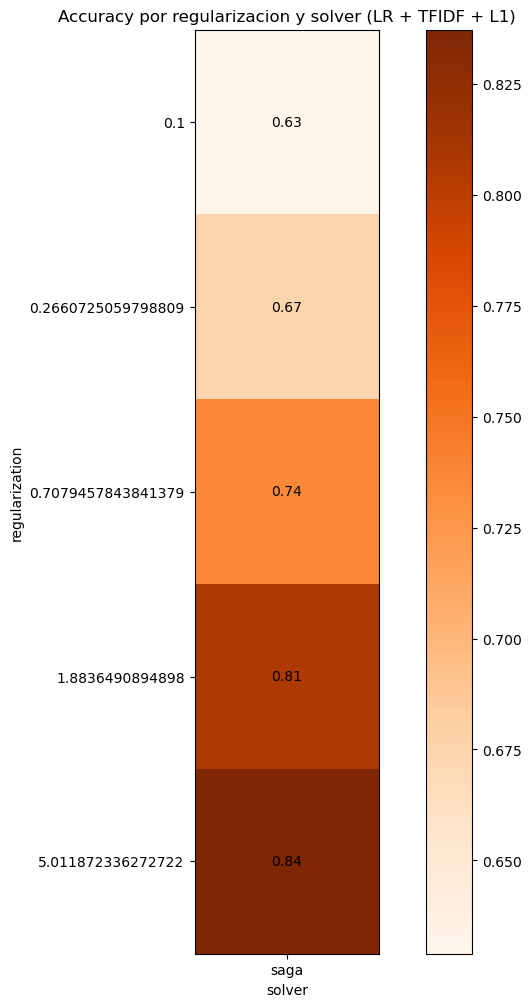

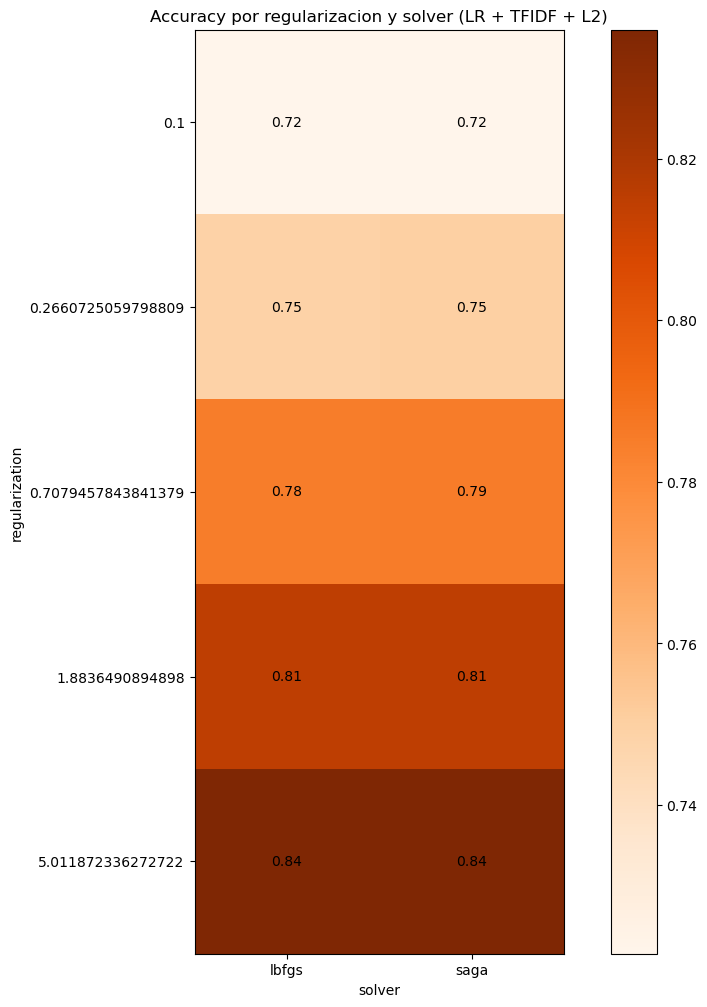

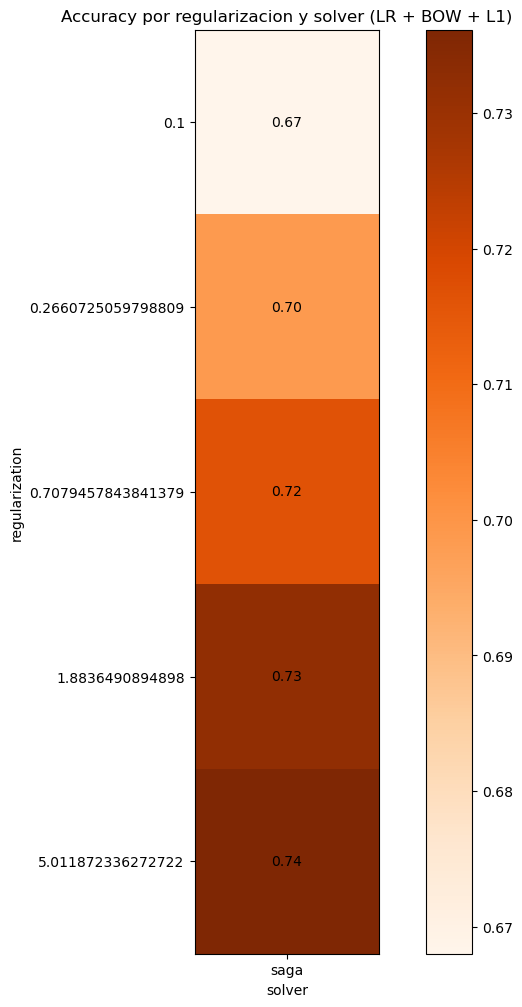

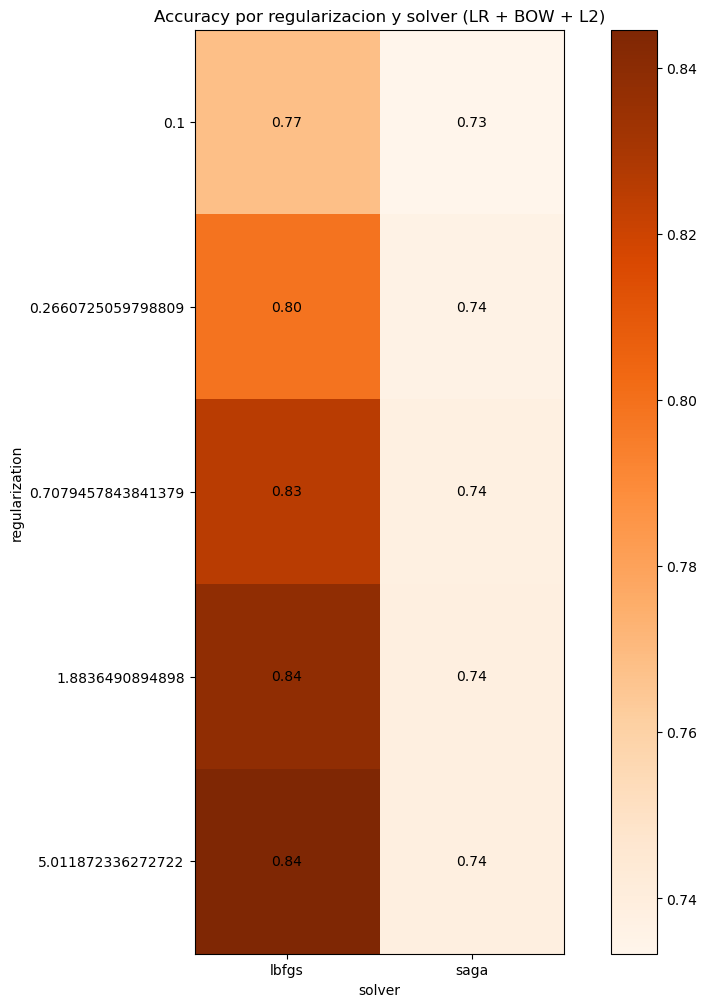

In [6]:
from constants.constants_twitter import LR_METRICS_PATH

# Cargar datos
df_lr = pd.read_csv(LR_METRICS_PATH)
display(df_lr.head())

# Devidir información
df_lr_tfidf_l1 = df_lr[(df_lr['vectorizer'] == 'TFIDF') & (df_lr['penalty']=="l1")]
df_lr_tfidf_l2 = df_lr[(df_lr['vectorizer'] == 'TFIDF') & (df_lr['penalty']=="l2")]
df_lr_bow_l1 = df_lr[(df_lr['vectorizer'] == 'BOW') & (df_lr['penalty']=="l1")]
df_lr_bow_l2 = df_lr[(df_lr['vectorizer'] == 'BOW') & (df_lr['penalty']=="l2")]

# Obtener hiperparámetros
df_lr_tfidf_l1_data = df_lr_tfidf_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_tfidf_l2_data = df_lr_tfidf_l2.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_bow_l1_data = df_lr_bow_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_bow_l2_data = df_lr_bow_l2.pivot(index="regularization", columns="solver", values="accuracy")

# Graficar
show_heatmap(df_lr_tfidf_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + TFIDF + L1)", (12, 12))
show_heatmap(df_lr_tfidf_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + TFIDF + L2)", (12, 12))
show_heatmap(df_lr_bow_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + BOW + L1)", (12, 12))
show_heatmap(df_lr_bow_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + BOW + L2)", (12, 12))

## SWEM

,accuracy,recall,precision,f1_score,model,classifier,pooling,penalty,kernel,regularization,max_iter,solver,embedding_dim,train_time,name
0,0.638949,0.638957,0.639136,0.637457,SWEM,svm,aver,NaN,linear,0.100000,NaN,NaN,100,162.375397,svm_model_1
1,0.577278,0.577284,0.576685,0.576442,SWEM,svm,max,NaN,linear,0.100000,NaN,NaN,100,183.365315,svm_model_2
2,0.668141,0.668148,0.668926,0.667108,SWEM,svm,aver,NaN,rbf,0.100000,NaN,NaN,100,184.301186,svm_model_3
3,0.622773,0.622775,0.622692,0.622717,SWEM,svm,max,NaN,rbf,0.100000,NaN,NaN,100,205.186868,svm_model_4
4,0.639075,0.639083,0.639120,0.637666,SWEM,svm,aver,NaN,linear,0.237137,NaN,NaN,100,165.543507,svm_model_5


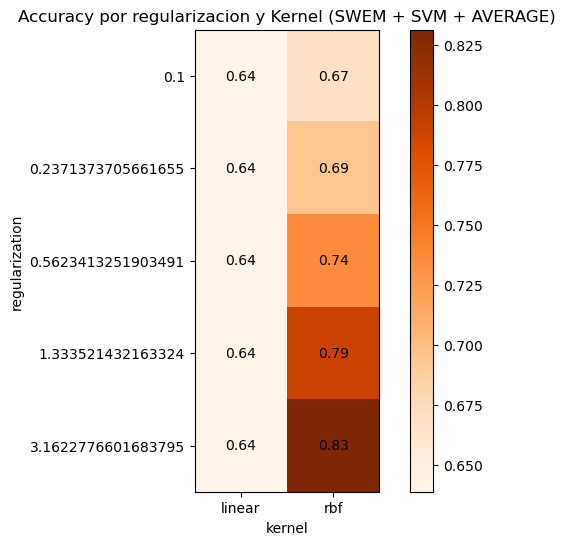

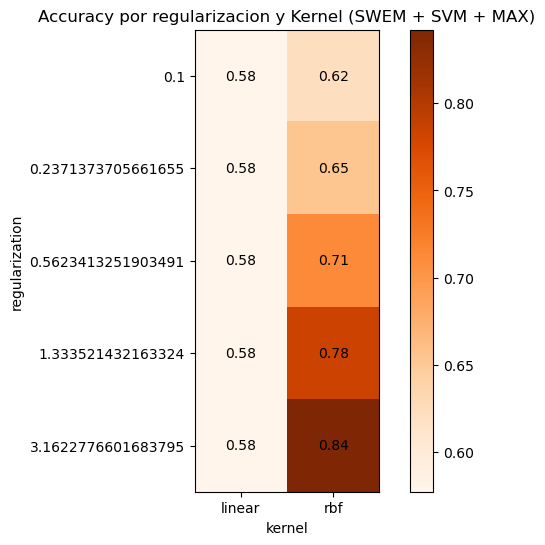

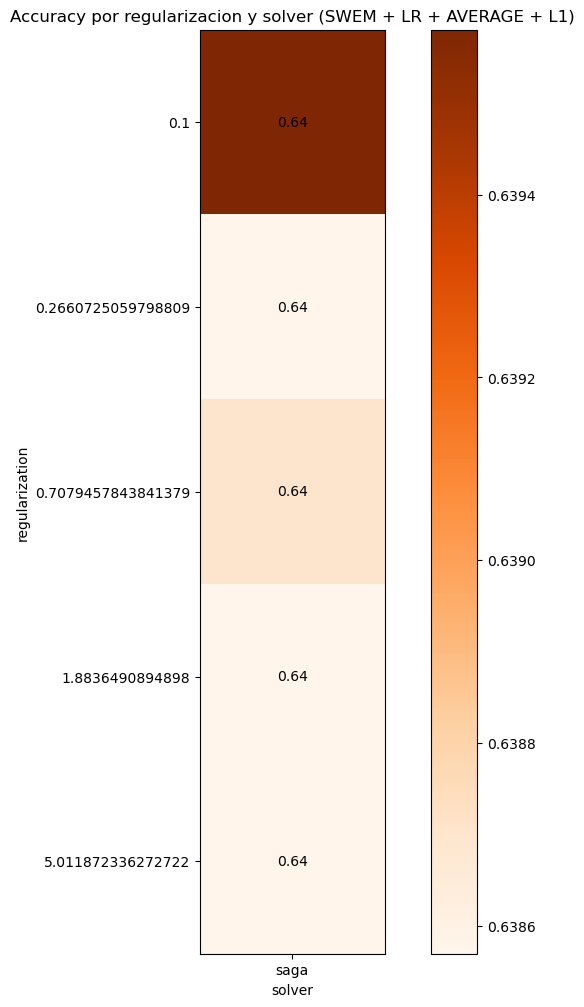

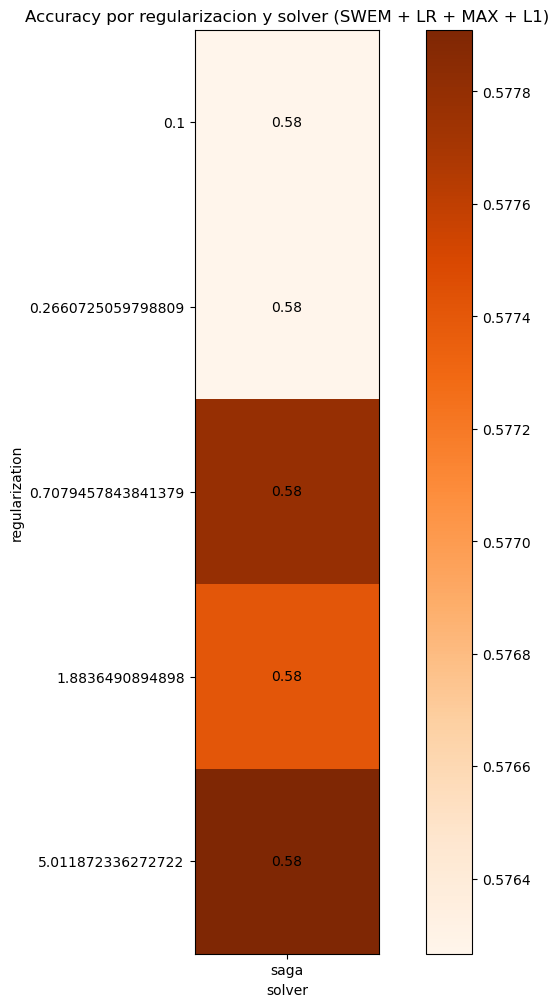

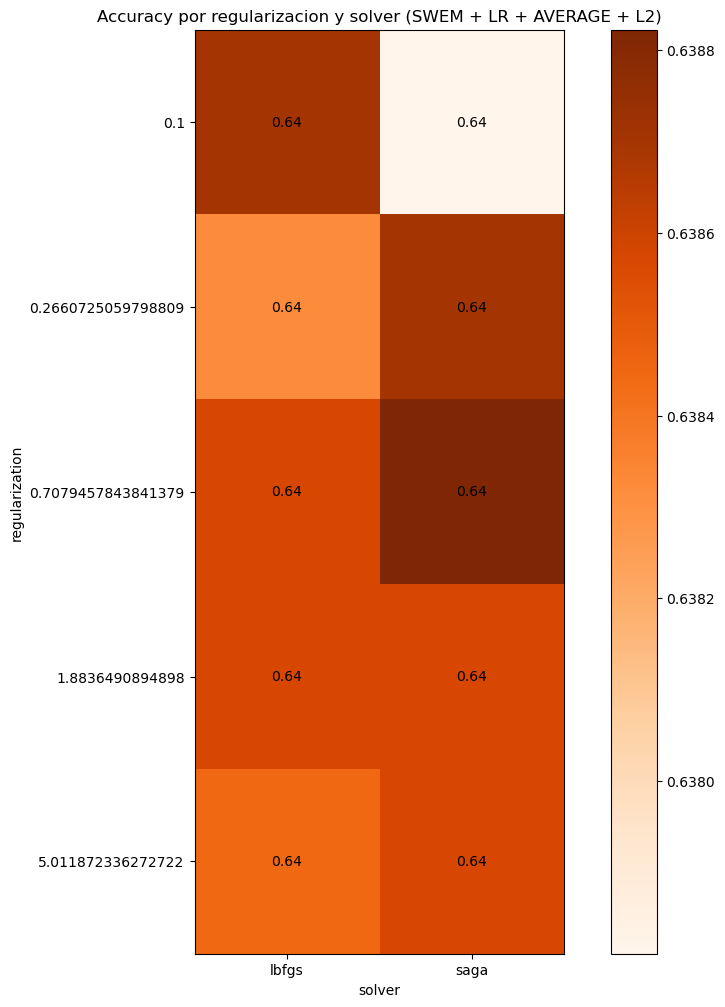

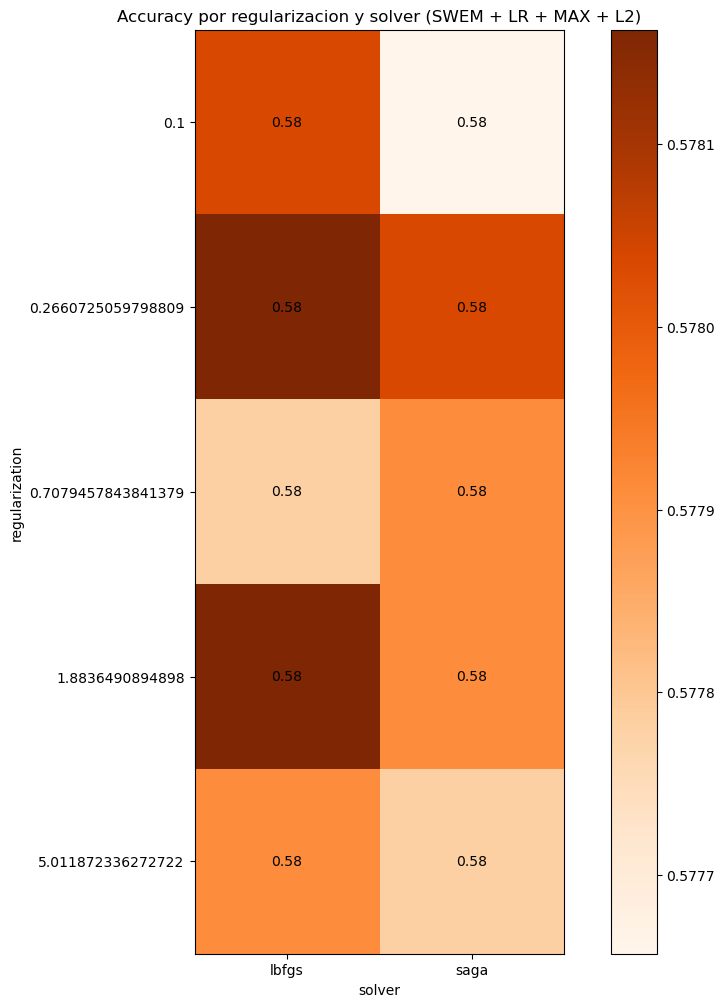

In [7]:

from constants.constants_twitter import SWEM_METRICS_PATH

# Cargar datos
df_swem = pd.read_csv(SWEM_METRICS_PATH)
display(df_swem.head())

# Devidir información
df_swem_svm_aver = df_swem[(df_swem['classifier'] == 'svm') & (df_swem['pooling'] == "aver")]
df_swem_svm_max = df_swem[(df_swem['classifier'] == 'svm') & (df_swem['pooling'] == "max")]
df_swem_lr_aver_l1 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "aver") & (df_swem['penalty'] == "l1")]
df_swem_lr_max_l1 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "max") & (df_swem['penalty'] == "l1")]
df_swem_lr_aver_l2 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "aver") & (df_swem['penalty'] == "l2")]
df_swem_lr_max_l2 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "max") & (df_swem['penalty'] == "l2")]

# Obtener hiperparámetros
df_swem_svm_aver_data = df_swem_svm_aver.pivot(index="regularization", columns="kernel", values="accuracy")
df_swem_svm_max_data = df_swem_svm_max.pivot(index="regularization", columns="kernel", values="accuracy")
df_swem_lr_aver_l1_data = df_swem_lr_aver_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_max_l1_data = df_swem_lr_max_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_aver_l2_data = df_swem_lr_aver_l2.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_max_l2_data = df_swem_lr_max_l2.pivot(index="regularization", columns="solver", values="accuracy")

# Graficar
show_heatmap(df_swem_svm_aver_data, "kernel", "regularization", "Accuracy por regularizacion y Kernel (SWEM + SVM + AVERAGE)")
show_heatmap(df_swem_svm_max_data, "kernel", "regularization", "Accuracy por regularizacion y Kernel (SWEM + SVM + MAX)")
show_heatmap(df_swem_lr_aver_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + AVERAGE + L1)", (12,12))
show_heatmap(df_swem_lr_max_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + MAX + L1)", (12,12))
show_heatmap(df_swem_lr_aver_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + AVERAGE + L2)", (12,12))
show_heatmap(df_swem_lr_max_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + MAX + L2)", (12,12))

## MLP

,accuracy,recall,precision,f1_score,model,pooling,optim,lr,patience,min_delta,hidden_layers,output_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.841779,0.841779,0.841969,0.841805,MLP SWEM,aver,adam,0.001000,15,0.0001,"[128, 64]",3,0.2,107/200,64,100,126.469255,model_1
1,0.760015,0.760013,0.760847,0.760063,MLP SWEM,max,adam,0.001000,15,0.0001,"[128, 64]",3,0.2,110/200,64,100,130.378009,model_2
2,0.649438,0.649446,0.649746,0.647930,MLP SWEM,aver,sgd,0.001000,15,0.0001,"[128, 64]",3,0.2,200/200,64,100,203.376288,model_3
3,0.594970,0.594976,0.595124,0.593407,MLP SWEM,max,sgd,0.001000,15,0.0001,"[128, 64]",3,0.2,200/200,64,100,206.742464,model_4
4,0.840389,0.840386,0.842093,0.840513,MLP SWEM,aver,adam,0.001995,15,0.0001,"[128, 64]",3,0.2,90/200,64,100,105.312797,model_5


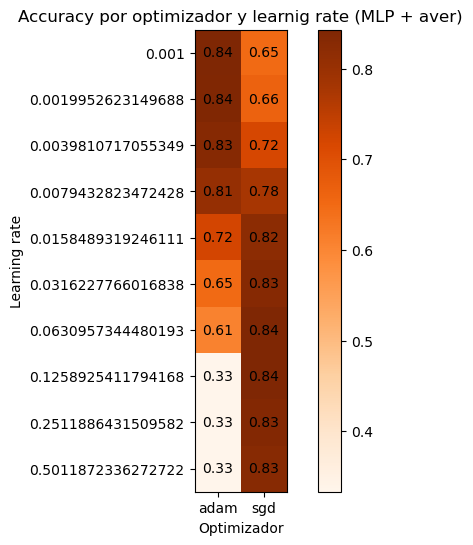

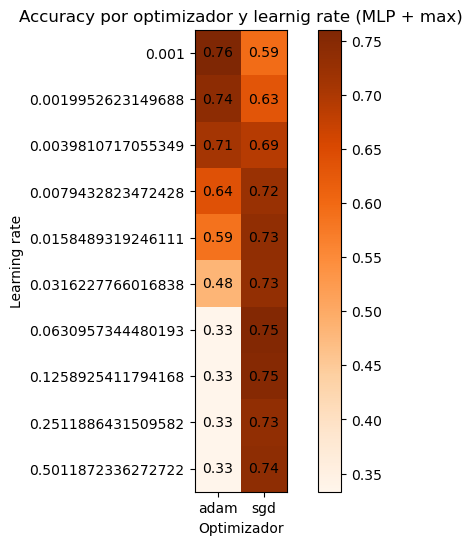

In [8]:
from constants.constants_twitter import MLP_METRICS_PATH

# Cargar datos
df_mlp = pd.read_csv(MLP_METRICS_PATH)
display(df_mlp.head())

# Dividir informacion
df_mlp_aver = df_mlp[df_mlp['pooling'] == "aver"]
df_mlp_max = df_mlp[df_mlp['pooling'] == "max"]

# Obtener hiperparámetros
df_mlp_aver_data = df_mlp_aver.pivot(index="lr", columns="optim", values="accuracy")
df_mlp_max_data = df_mlp_max.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_mlp_aver_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP + aver)")
show_heatmap(df_mlp_max_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP + max)")


## RNN

,accuracy,recall,precision,f1_score,model,optim,lr,patience,min_delta,num_layers,hidden_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.754202,0.754205,0.754300,0.753956,RNN,adam,0.001000,15,0.0001,2,128,0.2,35/200,64,100,149.788138,model_1
1,0.664223,0.664231,0.666779,0.662129,RNN,sgd,0.001000,15,0.0001,2,128,0.2,200/200,64,100,787.371989,model_2
2,0.633009,0.633018,0.638610,0.629762,RNN,adam,0.001995,15,0.0001,2,128,0.2,38/200,64,100,155.248592,model_3
3,0.690888,0.690898,0.697535,0.689037,RNN,sgd,0.001995,15,0.0001,2,128,0.2,200/200,64,100,788.839915,model_4
4,0.500063,0.500044,0.539759,0.496724,RNN,adam,0.003981,15,0.0001,2,128,0.2,20/200,64,100,83.091226,model_5


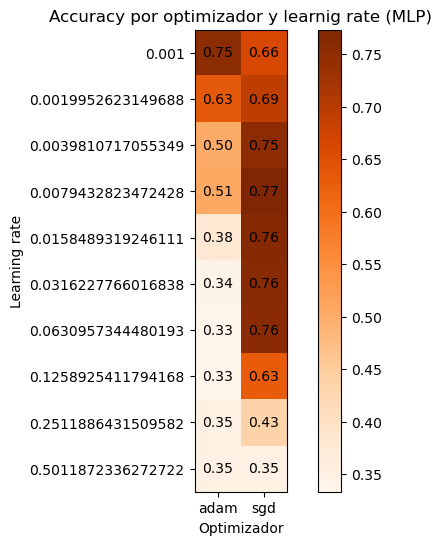

In [9]:
from constants.constants_twitter import RNN_METRICS_PATH

# Cargar datos
df_rnn = pd.read_csv(RNN_METRICS_PATH)
display(df_rnn.head())

# Obtener hiperparámetros
df_rnn_data= df_rnn.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_rnn_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP)")


## LSTM

,accuracy,recall,precision,f1_score,model,optim,lr,patience,min_delta,num_layers,hidden_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.895994,0.895995,0.896480,0.896029,LSTM,adam,0.001000,15,0.0001,2,128,0.2,200,64,100,144.622750,model_1
1,0.633262,0.633268,0.634772,0.631658,LSTM,sgd,0.001000,15,0.0001,2,128,0.2,200,64,100,888.239293,model_2
2,0.900164,0.900164,0.900253,0.900175,LSTM,adam,0.001995,15,0.0001,2,128,0.2,200,64,100,117.564370,model_3
3,0.649817,0.649825,0.651153,0.648109,LSTM,sgd,0.001995,15,0.0001,2,128,0.2,200,64,100,891.608283,model_4
4,0.889549,0.889551,0.890359,0.889551,LSTM,adam,0.003981,15,0.0001,2,128,0.2,200,64,100,99.665685,model_5


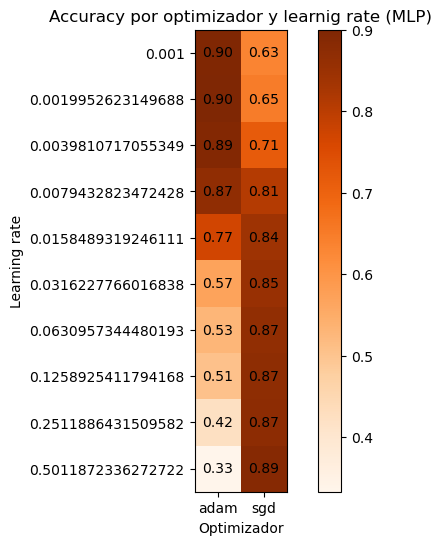

In [10]:
from constants.constants_twitter import LSTM_METRICS_PATH

# Cargar datos
df_lstm = pd.read_csv(LSTM_METRICS_PATH)
display(df_lstm.head())

# Obtener hiperparámetros
df_lstm_data = df_lstm.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_lstm_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP)")
